# Classification (refactored)

This notebook provides a reproducible pipeline for the scikit-learn breast cancer dataset.
Changes compared to the original notebook:
- Consistent random_state for reproducibility
- Stratified train/validation/test split
- sklearn Pipeline with StandardScaler + XGBoost classifier
- RandomizedSearchCV for hyperparameter tuning (ROC AUC scoring)
- Evaluation with accuracy, ROC AUC and classification report
- Model saving with joblib


In [1]:
# Core imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, classification_report, confusion_matrix, accuracy_score)
from xgboost import XGBClassifier
import joblib
import warnings

warnings.filterwarnings('ignore')
RANDOM_STATE = 42


In [2]:
# Load dataset
cancer = datasets.load_breast_cancer(as_frame=True)
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = pd.Series(cancer.target, name='target')

# Train / validation / test split (60/20/20) using stratify to preserve class balance
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, stratify=y_trainval, random_state=RANDOM_STATE)

print('Shapes: X_train', X_train.shape, 'X_val', X_val.shape, 'X_test', X_test.shape)


Shapes: X_train (341, 30) X_val (114, 30) X_test (114, 30)


In [3]:
# Build a pipeline: scaler + XGBoost
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_STATE))
])

param_dist = {
    'clf__n_estimators': [50, 100, 200, 400],
    'clf__max_depth': [3, 4, 5, 6],
    'clf__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'clf__subsample': [0.6, 0.8, 1.0],
    'clf__colsample_bytree': [0.5, 0.7, 1.0],
    'clf__reg_alpha': [0.0, 0.01, 0.1],
    'clf__reg_lambda': [1.0, 1.5, 2.0],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
search = RandomizedSearchCV(
    pipeline, param_distributions=param_dist, n_iter=30, scoring='roc_auc',
    n_jobs=-1, cv=cv, verbose=1, random_state=RANDOM_STATE
)

search.fit(X_train, y_train)
print('Best params:', search.best_params_)
print('Best CV score (roc_auc):', search.best_score_)


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'clf__subsample': 0.8, 'clf__reg_lambda': 1.0, 'clf__reg_alpha': 0.1, 'clf__n_estimators': 50, 'clf__max_depth': 5, 'clf__learning_rate': 0.1, 'clf__colsample_bytree': 1.0}
Best CV score (roc_auc): 0.9950242780475339


Validation accuracy: 0.9649122807017544
Validation ROC AUC: 0.9914837864395677
Classification report (validation):
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        43
           1       0.97      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



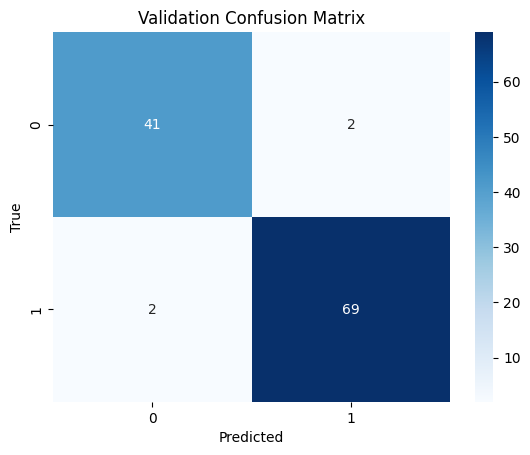

In [5]:
# Evaluate on validation set
best_model = search.best_estimator_
y_val_pred = best_model.predict(X_val)
y_val_proba = best_model.predict_proba(X_val)[:, 1] if hasattr(best_model, 'predict_proba') else None

print('Validation accuracy:', accuracy_score(y_val, y_val_pred))
if y_val_proba is not None:
    print('Validation ROC AUC:', roc_auc_score(y_val, y_val_proba))
print('Classification report (validation):')
print(classification_report(y_val, y_val_pred))

# Confusion matrix heatmap
cm = confusion_matrix(y_val, y_val_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Validation Confusion Matrix')
plt.show()


Test accuracy: 0.9385964912280702
Test ROC AUC: 0.9917328042328042
Classification report (test):
              precision    recall  f1-score   support

           0       0.91      0.93      0.92        42
           1       0.96      0.94      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



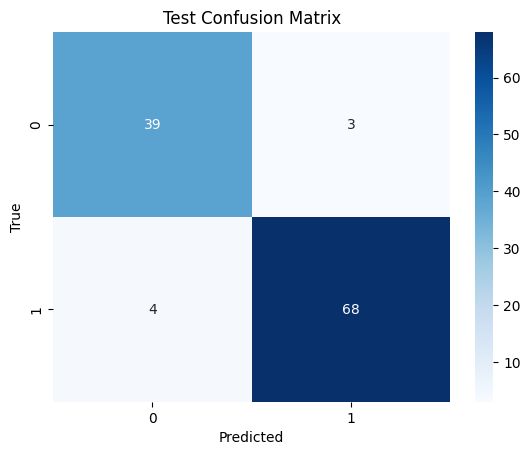

In [7]:
# Final evaluation on hold-out test set
y_test_pred = best_model.predict(X_test)
y_test_proba = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, 'predict_proba') else None

print('Test accuracy:', accuracy_score(y_test, y_test_pred))
if y_test_proba is not None:
    print('Test ROC AUC:', roc_auc_score(y_test, y_test_proba))
print('Classification report (test):')
print(classification_report(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Test Confusion Matrix')
plt.show()


In [8]:
# Save the best pipeline to disk
joblib.dump(best_model, 'xgb_pipeline.joblib')
print('Saved model to xgb_pipeline.joblib')


Saved model to xgb_pipeline.joblib


Next steps / notes:
- Consider using Optuna for more efficient hyperparameter optimization.
- Use SHAP or permutation importance for model explainability.
- If you need GPU acceleration for XGBoost/LightGBM, adjust the estimator parameters accordingly.
- Add a small script (train.py) and requirements.txt for reproducibility and CI.
